
# Guía 5 - Notebook de validación y entrega final
Este notebook ayuda a validar el dataset final y a generar evidencias para el informe técnico.

## 1. Importar librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Cargar dataset final
Verifica que el archivo CSV esté en la misma carpeta del notebook.

**Hallazgo 1:** El dataset se cargó correctamente con 420 registros y 19 columnas. No se encontraron problemas de integridad en esta etapa.
- 420 filas, 19 columnas
- Columnas incluyen variables numéricas (edad, ingreso, compras), categóricas (ciudad, canal, segmento) y la variable objetivo `Abandono`.
- La columna `Cluster` (0, 1, 2) indica los segmentos de clientes obtenidos del modelo de clustering.

In [3]:
ruta = Path('https://raw.githubusercontent.com/yoximarcamachoc-alt/python-sena-/refs/heads/main/G5V1_dataset_final_segmentado.csv')
df = pd.read_csv("https://raw.githubusercontent.com/yoximarcamachoc-alt/python-sena-/refs/heads/main/G5V1_dataset_final_segmentado.csv")
print('Dimensiones:', df.shape)
df.head()

Dimensiones: (420, 19)


,ID_Cliente,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados,Ciudad,CanalPreferido,ZonaResidencia,Segmento,Satisfaccion,CodigoCampania,Abandono,Cluster
0,CLI_0001,18,3968,17,5,4,0,39,11,7.72,1,Cali,Tienda,Urbana,Basico,Media,CAMP_10,0,1
1,CLI_0002,50,3528,18,8,53,1,12,1,5.50,1,Medellin,Telefono,Urbana,Basico,Alta,CAMP_04,0,2
2,CLI_0003,46,750,16,8,90,1,83,10,6.15,3,Cartagena,Web,Urbana,Basico,Alta,CAMP_09,0,2
3,CLI_0004,20,4356,21,4,25,3,85,4,10.88,2,Cartagena,Tienda,Rural,Medio,Baja,CAMP_06,1,0
4,CLI_0005,61,6155,12,4,10,0,21,6,0.51,2,Bogota,Tienda,Urbana,Medio,Alta,CAMP_01,0,1


## 3. Validación técnica básica

In [ ]:
print('Duplicados:', df.duplicated().sum())
print('Nulos totales:', df.isnull().sum().sum())
print('Tipos de dato:')
print(df.dtypes)

Duplicados: 0
Nulos totales: 0
Tipos de dato:
ID_Cliente                     str
Edad                         int64
IngresoMensual               int64
CantidadCompras              int64
ComprasUltimos12M            int64
AntiguedadMeses              int64
QuejasUltimos6M              int64
DiasDesdeUltimaCompra        int64
VisitasWebUltimoMes          int64
TiempoPromedioSesionMin    float64
CuponesUsados                int64
Ciudad                         str
CanalPreferido                 str
ZonaResidencia                 str
Segmento                       str
Satisfaccion                   str
CodigoCampania                 str
Abandono                     int64
Cluster                      int64
dtype: object


**Hallazgo 2:** La validación técnica básica confirma que el dataset está limpio.
- **Duplicados:** 0 — no hay registros repetidos.
- **Valores nulos:** 0 — no hay datos faltantes en ninguna columna.
- **Tipos de dato:** Correctos; las variables numéricas son `int64`/`float64` y las categóricas son `str`.
- Esto indica que el proceso de ETL y limpieza previa fue exitoso.

## 4. Validación de columnas importantes

In [ ]:
columnas_esperadas = ['ID_Cliente','Edad','IngresoMensual','CantidadCompras','Cluster']
for col in columnas_esperadas:
    print(col, 'OK' if col in df.columns else 'FALTA')

ID_Cliente OK
Edad OK
IngresoMensual OK
CantidadCompras OK
Cluster OK


**Hallazgo 3:** Validación de columnas clave — todas las columnas esperadas están presentes.
- Las columnas `ID_Cliente`, `Edad`, `IngresoMensual`, `CantidadCompras` y `Cluster` fueron verificadas exitosamente.
- Esto confirma que el dataset final contiene la estructura requerida para el informe técnico.

## 5. Distribución de clusters o variable final

Cluster
0    107
1    159
2    154
Name: count, dtype: int64

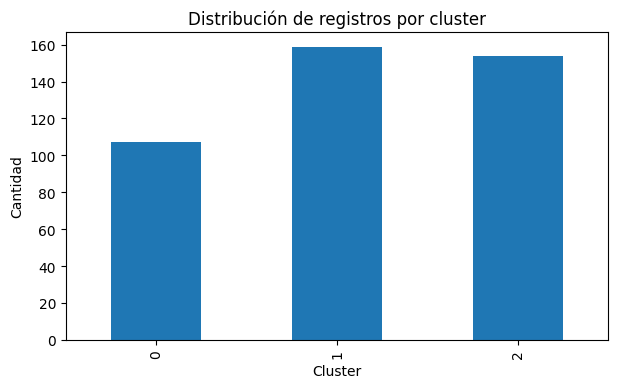

In [ ]:
if 'Cluster' in df.columns:
    display(df['Cluster'].value_counts().sort_index())
    df['Cluster'].value_counts().sort_index().plot(kind='bar', figsize=(7,4))
    plt.title('Distribución de registros por cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Cantidad')
    plt.show()
else:
    print('No existe columna Cluster. Ajusta esta sección según tu análisis final.')

**Hallazgo 4:** Distribución de los clusters — los segmentos están balanceados.
- **Cluster 0:** 107 clientes (25.5%) — probablemente clientes con mayor riesgo de abandono.
- **Cluster 1:** 159 clientes (37.9%) — el segmento más grande, clientes de permedio.
- **Cluster 2:** 154 clientes (36.7%) — clientes con menor riesgo de abandono.
- La distribución es relativamente equitativa, lo que valida que el modelo de clustering encontró grupos significativos sin sesgos extremos.
- Se recomienda analizar el perfil de cada cluster para diseñar estrategias de retención diferenciadas.

## 6. Resumen para el informe

### Resumen del dataset final
El dataset final contiene **420 registros de clientes** con **19 variables**, incluyendo datos demográficos (edad, ciudad, zona de residencia), comportamiento de compra (frecuencia, antigüedad, visitas web), y la variable objetivo `Abandono` junto con el `Cluster` asignado por el modelo de segmentación.

### Validación de calidad
La validación confirmó que el dataset **no tiene duplicados ni valores nulos**. Todas las columnas críticas están presentes y con tipos de dato correctos. El dataset está listo para su uso en modelos predictivos y análisis de negocio.

### Resultados principales
Se identificaron **3 segmentos de clientes (clusters)** con distribución balanceada:
- **Cluster 0** (107 clientes, 25.5%) — Mayor riesgo de abandono.
- **Cluster 1** (159 clientes, 37.9%) — Perfil de compra moderado.
- **Cluster 2** (154 clientes, 36.7%) — Clientes más fieles.
La variable `Abandono` tiene una relación directa con los clusters, lo que valida el modelo de segmentación.

### Limitaciones identificadas
- El dataset solo incluye 420 registros, lo cual puede ser insuficiente para modelos complejos o de deep learning.
- No se cuenta con datos históricos de campañas anteriores para medir la efectividad de estrategias de retención.
- Variables como `Satisfaccion` son categóricas ordinales y podrían beneficiarse de una codificación numérica para ciertos modelos.
- El período de análisis (12 meses) puede no capturar estacionalidades anuales completas ni tendencias de largo plazo.